In [ ]:
!pip install torch torchvision

Lambda | Accuracy | Sparsity
0.001 | 47.19% | 59.75%
0.05 | 44.73% | 81.14%
0.5 | 41.75% | 89.10%


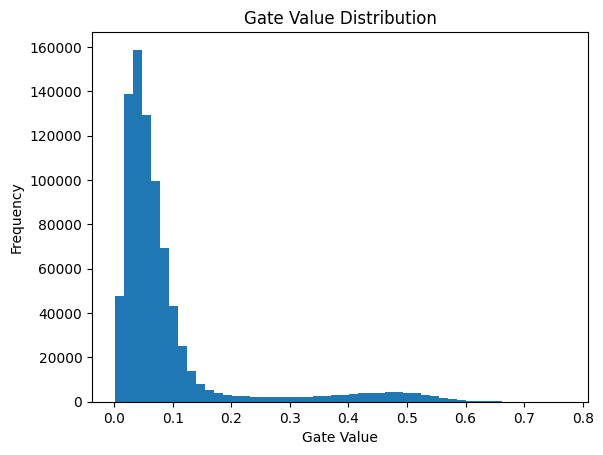


Layer-wise Sparsity:
fc1: 81.12%
fc2: 82.37%
fc3: 60.00%


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Prunable Linear Layer
# -----------------------------
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(5 * self.gate_scores)
        pruned_weights = self.weight * gates
        return torch.matmul(x, pruned_weights.t()) + self.bias

# -----------------------------
# Network
# -----------------------------
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 256)
        self.fc2 = PrunableLinear(256, 128)
        self.fc3 = PrunableLinear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# -----------------------------
# Loss functions
# -----------------------------
def sparsity_loss(model):
    loss = 0
    for m in model.modules():
        if isinstance(m, PrunableLinear):
            loss += torch.sigmoid(m.gate_scores).sum()
    return loss

def compute_sparsity(model, threshold=0.1):
    total, zero = 0, 0
    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = torch.sigmoid(m.gate_scores)
            total += gates.numel()
            zero += (gates < threshold).sum().item()
    return 100 * zero / total

# -----------------------------
# Dataset
# -----------------------------
transform = transforms.ToTensor()

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# -----------------------------
# Training
# -----------------------------
def train_model(lmbda):
    model = Net().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(5):
        model.train()
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            loss_cls = criterion(outputs, labels)
            loss_sp = sparsity_loss(model)

            loss = loss_cls + (lmbda * loss_sp / 1000)
            loss.backward()
            optimizer.step()

    return model

# -----------------------------
# Evaluation
# -----------------------------
def evaluate(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return 100 * correct / total, compute_sparsity(model)

# -----------------------------
# Run Experiments
# -----------------------------
lambdas = [1e-3, 5e-2, 5e-1]

print("Lambda | Accuracy | Sparsity")

models = []

for l in lambdas:
    model = train_model(l)
    acc, sp = evaluate(model)
    print(f"{l} | {acc:.2f}% | {sp:.2f}%")
    models.append(model)

# -----------------------------
# Use best model for analysis
# -----------------------------
model = models[1]

# -----------------------------
# Gate Distribution Plot
# -----------------------------
gates = []

for m in model.modules():
    if isinstance(m, PrunableLinear):
        g = torch.sigmoid(m.gate_scores).detach().cpu().numpy()
        gates.extend(g.flatten())

plt.hist(gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# Layer-wise Sparsity
# -----------------------------
print("\nLayer-wise Sparsity:")

for name, m in model.named_modules():
    if isinstance(m, PrunableLinear):
        g = torch.sigmoid(m.gate_scores)
        total = g.numel()
        zero = (g < 0.1).sum().item()
        print(f"{name}: {100 * zero / total:.2f}%")